# LAB TỔNG HỢP: DEEP LEARNING CƠ BẢN (CHAPTER 1–4)

Môn học: Deep Learning
Mục tiêu: Giúp sinh viên hiểu và thực hành các khái niệm cơ bản về neural network, TensorFlow/Keras, classification và regression. Khi train models sinh viên phải xác định số epochs phù hợp để có models tốt và lý giải lý do tại sao chọn như vậy.


## PHẦN 1: CÂU HỎI LÝ THUYẾT (Chapter 1)

Sinh viên trả lời trực tiếp vào notebook:

1. Deep Learning là gì? Phân biệt với Machine Learning truyền thống.

    Deep Learning (Học sâu) là một nhánh phụ của lĩnh vực Machine Learning. Bản chất của Deep Learning cũng không khác với Machine Learning về cấu trúc thuật toán cho học máy giúp xử lý các dữ liệu. 

    Tuy vậy DL lại có mô hình phỏng theo hệ thần kinh neuron với nhiều lớp hơn giúp máy học tự học, chọn lọc/phân loại các đặc trưng, đồng thời xử lý và biểu diễn dữ liệu nhằm giải quyết những bài toán/vấn đề lớn hơn.

2. Neural Network hoạt động như thế nào?

Neural Network như một hệ thống các "bộ lọc" xếp chồng lên nhau:
- Input Layer (Đầu vào): Tiếp nhận dữ liệu (ví dụ: các thông số căn nhà như diện tích, số phòng).
- Hidden Layers (Lớp ẩn): Tại đây, mỗi node (neuron) sẽ thực hiện phép tính: (Dữ liệu × Trọng số) + Sai số. Trọng số (weight) càng lớn nghĩa là đặc trưng đó càng quan trọng. Sau đó, một "hàm kích hoạt" (activation function) sẽ quyết định tín hiệu nào được truyền tiếp đi.
- Output Layer (Đầu ra): Đưa ra dự đoán cuối cùng (giá nhà).
- Cơ chế học: Mô hình so sánh dự đoán với thực tế. Nếu sai, nó dùng thuật toán (Backpropagation) để quay ngược lại điều chỉnh các trọng số sao cho lần sau sai số ít đi.

3. Vai trò của dữ liệu trong deep learning.

- Quyết định độ chính xác: Deep Learning khác Machine Learning truyền thống ở chỗ: càng nhiều dữ liệu, nó càng thông minh (không bị bão hòa sớm).
- Định hình hành vi: Nếu dữ liệu bị sai lệch (ví dụ: chỉ toàn dữ liệu nhà giàu), mô hình sẽ dự đoán sai về thực tế chung.
- Dạy đặc trưng: Thay vì con người phải chỉ cho máy "đây là cửa sổ", "đây là cửa chính", mô hình tự nhìn hàng triệu tấm ảnh để rút ra các đặc điểm đó nhờ lượng dữ liệu khổng lồ.

4. Overfitting là gì? Cho ví dụ.

Overfitting (Quá khớp) là hiện tượng mô hình học quá chi tiết vào dữ liệu huấn luyện, bao gồm cả những nhiễu (noise) hoặc những chi tiết ngẫu nhiên không lặp lại ở thực tế. Hiểu đơn giản là máy học vẹt thay vì học hiểu.

Ví dụ: Dạy máy nhận diện con chó bằng 100 tấm ảnh mà trong đó tất cả con chó đều đeo vòng cổ màu đỏ. Thay vì học hình dạng của những con chó thì nó sẽ dựa vào chiếc vòng cổ. Nên nếu khi đưa một con chó khác không có vòng cổ (không trong tệp huấn luyện) thì máy không định dạng được

## PHẦN 2: TOÁN HỌC CƠ BẢN (Chapter 2)

### Bài tập 1: Vector và ma trận
Cho vector x = [1, 2, 3] và w = [0.2, 0.5, 0.3]

Yêu cầu:
- Tính dot product
- Tính sigmoid(dot)


In [3]:
import numpy as np

x = np.array([1, 2, 3])
w = np.array([0.2, 0.5, 0.3])

# TODO: tính dot product
z = np.dot(x,w)
print("Dot:",z)

# TODO: tính sigmoid
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

print("Sigmoid:", sigmoid(z))

Dot: 2.0999999999999996
Sigmoid: 0.8909031788043871


### Bài tập 2: Gradient đơn giản
Cho hàm f(x) = x^2

Yêu cầu:
- Tính đạo hàm
- Viết code tính gradient tại x = 3


In [4]:
# TODO: tính gradient của f(x) = x^2 tại x = 3
x = 3
f = x**2

print("Gradient f(x) = x^2, with x=3: ", f)

Gradient f(x) = x^2, with x=3:  9


## PHẦN 3: LÀM QUEN KERAS & TENSORFLOW (Chapter 3)

### Bài tập 3: Tạo model đơn giản

Yêu cầu:
- Tạo Sequential model
- 2 hidden layer (ReLU) gồm 6 và 8 output neurons
- 1 output layer (sigmoid)


In [5]:
from tensorflow import keras
from tensorflow.keras import layers

# TODO: xây dựng model
model = keras.Sequential([
    layers.Dense(6, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid') #binary classification
])

### Bài tập 4: Compile model

Yêu cầu:
- optimizer: adam
- loss: binary_crossentropy
- metrics: accuracy


In [6]:
# TODO: compile model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

## PHẦN 4: CLASSIFICATION (Chapter 4)

### Bài tập 5: Phân loại nhị phân

Dataset: Breast Cancer Wisconsin (sklearn)

Yêu cầu:
- Load dữ liệu
- Chia train/test
- Train model
- Evaluate accuracy


In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# TODO: load data
data = load_breast_cancer()

# TODO: split data
x = data.data
y = data.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# TODO: train model
model.fit(x_train, y_train, epochs=100, batch_size=32)

# TODO: evaluate
model.evaluate(x_test, y_test)


Epoch 1/100
15/15 [==============================] - 0s 986us/step - loss: 6.3462 - accuracy: 0.5099
Epoch 2/100
15/15 [==============================] - 0s 879us/step - loss: 1.6021 - accuracy: 0.3385
Epoch 3/100
15/15 [==============================] - 0s 786us/step - loss: 0.6741 - accuracy: 0.6264
Epoch 4/100
15/15 [==============================] - 0s 928us/step - loss: 0.5404 - accuracy: 0.7626
Epoch 5/100
15/15 [==============================] - 0s 857us/step - loss: 0.4823 - accuracy: 0.7582
Epoch 6/100
15/15 [==============================] - 0s 857us/step - loss: 0.4574 - accuracy: 0.8440
Epoch 7/100
15/15 [==============================] - 0s 786us/step - loss: 0.4313 - accuracy: 0.8571
Epoch 8/100
15/15 [==============================] - 0s 857us/step - loss: 0.4109 - accuracy: 0.8659
Epoch 9/100
15/15 [==============================] - 0s 857us/step - loss: 0.3956 - accuracy: 0.8769
Epoch 10/100
15/15 [==============================] - 0s 857us/step - loss: 0.3940 - accura

[0.17534694075584412, 0.9298245906829834]

### Bài tập 6: Phân tích kết quả

Yêu cầu:
- In confusion matrix
- Nhận xét model


In [10]:
from sklearn.metrics import confusion_matrix

# TODO: tính confusion matrix
y_pred = model.predict(x_test)
y_pred = np.round(y_pred)
cm = confusion_matrix(y_test, y_pred)
print(cm)

4/4 [==============================] - 0s 1ms/step
[[36  4]
 [ 4 70]]


## PHẦN 5: REGRESSION (Chapter 4)

### Bài tập 7: Dự đoán giá nhà

Dataset: California Housing

Yêu cầu:
- Xây dựng model regression
- Loss: mse
- Metric: mae


In [23]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.datasets import fetch_california_housing

# TODO: load data
data = fetch_california_housing()
x = data.data
y = data.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# TODO: build model regression
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# TODO: train
train = model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
413/413 [==============================] - 1s 1ms/step - loss: 172.2187 - mae: 4.0322 - val_loss: 3.2443 - val_mae: 0.9236
Epoch 2/50
413/413 [==============================] - 1s 1ms/step - loss: 9.0388 - mae: 1.5025 - val_loss: 1.7285 - val_mae: 0.8955
Epoch 3/50
413/413 [==============================] - 0s 961us/step - loss: 3.2083 - mae: 1.0501 - val_loss: 2.6605 - val_mae: 1.3862
Epoch 4/50
413/413 [==============================] - 0s 958us/step - loss: 3.0154 - mae: 1.1292 - val_loss: 2.4620 - val_mae: 1.2212
Epoch 5/50
413/413 [==============================] - 0s 956us/step - loss: 1.3776 - mae: 0.8182 - val_loss: 1.9224 - val_mae: 1.0172
Epoch 6/50
413/413 [==============================] - 0s 1ms/step - loss: 8.1244 - mae: 1.4117 - val_loss: 15.7440 - val_mae: 3.2604
Epoch 7/50
413/413 [==============================] - 0s 957us/step - loss: 1.3894 - mae: 0.8330 - val_loss: 1.2767 - val_mae: 0.8398
Epoch 8/50
413/413 [==============================] - 0s 950us/st

### Bài tập 8: Đánh giá mô hình regression

Yêu cầu:
- Tính MAE
- Vẽ biểu đồ loss


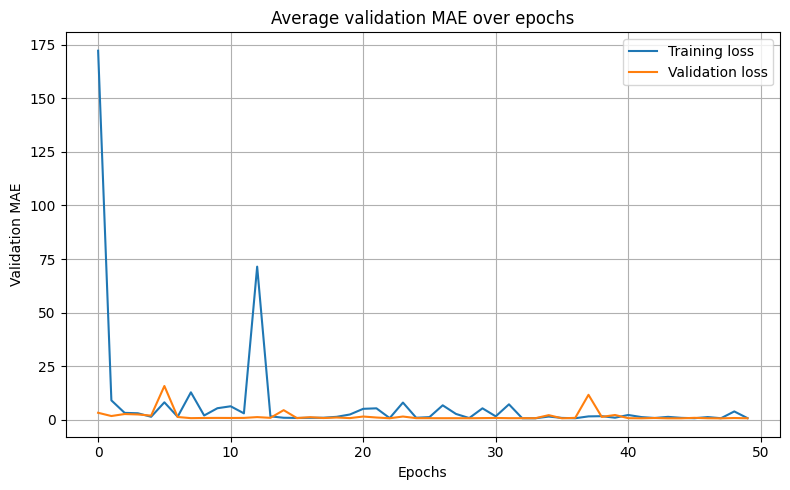

In [25]:
import matplotlib.pyplot as plt

# TODO: plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Average validation MAE over epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

## PHẦN 6: BÀI TẬP MỞ RỘNG

1. Thay đổi số layer → ảnh hưởng thế nào?

Số lượng layer quyết định "khả năng tư duy" của mô hình:

- Tăng thêm layer: Giúp mô hình học được các đặc trưng phức tạp hơn (ví dụ: từ các nét vẽ cơ bản đến hình dáng khuôn mặt). Tuy nhiên, quá nhiều layer dễ dẫn đến Overfitting (học vẹt) và tốn thời gian tính toán.

- Giảm bớt layer: Mô hình chạy nhanh hơn, nhẹ hơn nhưng nếu quá ít, nó sẽ không đủ khả năng hiểu dữ liệu (dẫn đến Underfitting).

2. Thay đổi learning rate → kết quả ra sao?

Learning rate giống như "độ dài bước chân" khi bạn đang xuống thung lũng để tìm điểm thấp nhất:

- Learning Rate cao (Bước quá dài): Bạn đi rất nhanh nhưng dễ bước hụt qua điểm tối ưu, thậm chí làm mô hình không thể hội tụ (kết quả nhảy loạn xạ).

- Learning Rate thấp (Bước quá ngắn): Bạn đi cực kỳ cẩn thận và chính xác, nhưng mất rất nhiều thời gian. Nếu quá thấp, mô hình có thể bị "kẹt" ở những chỗ chưa phải tốt nhất.

3. So sánh overfitting vs underfitting

| Đặc điểm | Underfitting | Overfitting |
|---|---|---|
|**Hiện tượng**|Mô hình quá đơn giản, kết quả kém trên cả tập Huấn luyện và Kiểm tra.|Mô hình học thuộc lòng dữ liệu huấn luyện, nhưng gặp dữ liệu mới là sai.|
|**Dấu hiệu**|Sai số (Loss) ở cả 2 tập đều cao.|Loss tập Huấn luyện rất thấp, nhưng Loss tập Kiểm tra lại rất cao.|
|**Cách khắc phục**|Tăng thêm layer, tăng số lượng đặc trưng (features).|Giảm bớt layer, thêm Dropout, hoặc lấy thêm dữ liệu|

Sinh viên viết nhận xét trực tiếp vào notebook.
